<a href="https://colab.research.google.com/github/REXXARII/BibliOsfera-API/blob/main/Evaluacion_Parcial_3_Mineria_Entregable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación 2: Minería de Datos Aplicada al Clima en Australia
**Fases 1 a 3 de la Metodología CRISP-DM**

---

## 1. Fase 1: Comprensión del Negocio (Business Understanding)

### Contexto del Dominio
Australia es uno de los países con mayor extensión mundial y, a su vez, el continente más seco y llano del planeta. Cerca de la mitad occidental es una extensa meseta árida y se estima que un 40% del territorio está compuesto por dunas de arena y clima desértico o semiárido. Las tierras fértiles, vitales para la economía y habitabilidad, se concentran en zonas muy específicas del sureste y suroeste, dependiendo fuertemente de los caudales que nacen en la Gran Cordillera Divisoria. En un escenario geográfico tan extremo, la variabilidad climática representa un riesgo constante.

### Objetivo del Proyecto y de la Minería de Datos
Anticipar los fenómenos meteorológicos, en particular las precipitaciones, tiene un impacto directo en la planificación logística, la prevención de desastres naturales y la optimización del sector agrícola.

Mi objetivo principal en este informe técnico es aplicar las tres primeras fases de la metodología CRISP-DM sobre el conjunto de datos históricos del clima australiano. Desde mi rol como desarrolladora y analista, busco transformar estos datos crudos en una base de información estructurada, limpia y matemáticamente sólida. Esta preparación es el paso crítico y necesario para que, en etapas posteriores, los modelos predictivos (supervisados y no supervisados) logren generalizar de forma correcta, evitando problemas graves como el *overfitting* (sobreajuste) o *underfitting* (subajuste).


## 2. Fase 2: Comprensión de los Datos (Data Understanding)

### 2.1. Importación de Librerías y Carga Inicial
El primer paso técnico consiste en configurar el entorno de desarrollo. Para ello, importo las librerías fundamentales para la manipulación de datos (`pandas`, `numpy`) y para la visualización estadística (`matplotlib`, `seaborn`).

A continuación, procedo a cargar el archivo `weatherAUS.csv` y ejecuto una auditoría estructural inicial para conocer la dimensionalidad (cantidad de registros y variables) y los tipos de datos que componen el *dataset*.


In [ ]:
# Importación de librerías esenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para mantener un estilo profesional en los gráficos
sns.set_theme(style="whitegrid")

# Carga del dataset (formato CSV optimizado para Pandas)
# Asegurar que el archivo 'weatherAUS.csv' esté subido al entorno de Colab
df = pd.read_csv('weatherAUS.csv')

# Auditoría inicial de dimensionalidad
filas, columnas = df.shape
print(f"Dimensionalidad del dataset: {filas} registros (filas) y {columnas} variables (columnas).\n")

# Despliegue de la información estructural y tipos de datos
print("Información detallada de las variables:")
df.info()


Dimensionalidad del dataset: 142193 registros (filas) y 24 variables (columnas).

Información detallada de las variables:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 1

### 2.2. Interpretación de la Estructura Inicial

Al analizar la salida de la auditoría preliminar, identifico varios puntos críticos que definirán mi estrategia en la fase de preparación:

1. **Volumen de Datos:** Trabajo con una matriz exacta de 142.193 registros y 24 columnas. Es un tamaño considerable, lo que me exige ser eficiente en las transformaciones para optimizar el uso de memoria RAM en el entorno.
2. **Naturaleza de las Variables:** Existe una clara división entre datos categóricos (tipo `object`, como *Location* o las direcciones del viento) y datos numéricos continuos (tipo `float64`, correspondientes a las mediciones físicas como temperatura, humedad o presión).
3. **Inconsistencia de Completitud:** Observo una discrepancia alarmante en la columna *Non-Null Count*. Mientras que variables como *Date* o *Location* están al 100%, otras como *Evaporation*, *Sunshine* o *Cloud9am* presentan vacíos significativos.

Para dimensionar exactamente la gravedad de esta pérdida de información, mi siguiente paso es cuantificar e ilustrar el porcentaje de valores nulos por cada variable.


### 2.3. Análisis Exploratorio: Cuantificación y Visualización de Valores Nulos

Antes de aplicar cualquier técnica de imputación, necesito evaluar matemáticamente la proporción de datos faltantes. La regla general en minería de datos dicta que si una variable supera un umbral crítico de nulos (típicamente entre 40% y 50%), su imputación estadística podría introducir demasiado ruido y sesgar el modelo, siendo preferible su eliminación.

A continuación, calculo el porcentaje exacto de nulos por columna y genero un gráfico de barras para identificar rápidamente las variables más comprometidas.


/tmp/ipykernel_6613/3023419750.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=porcentaje_nulos.index, y=porcentaje_nulos.values, palette="rocket")


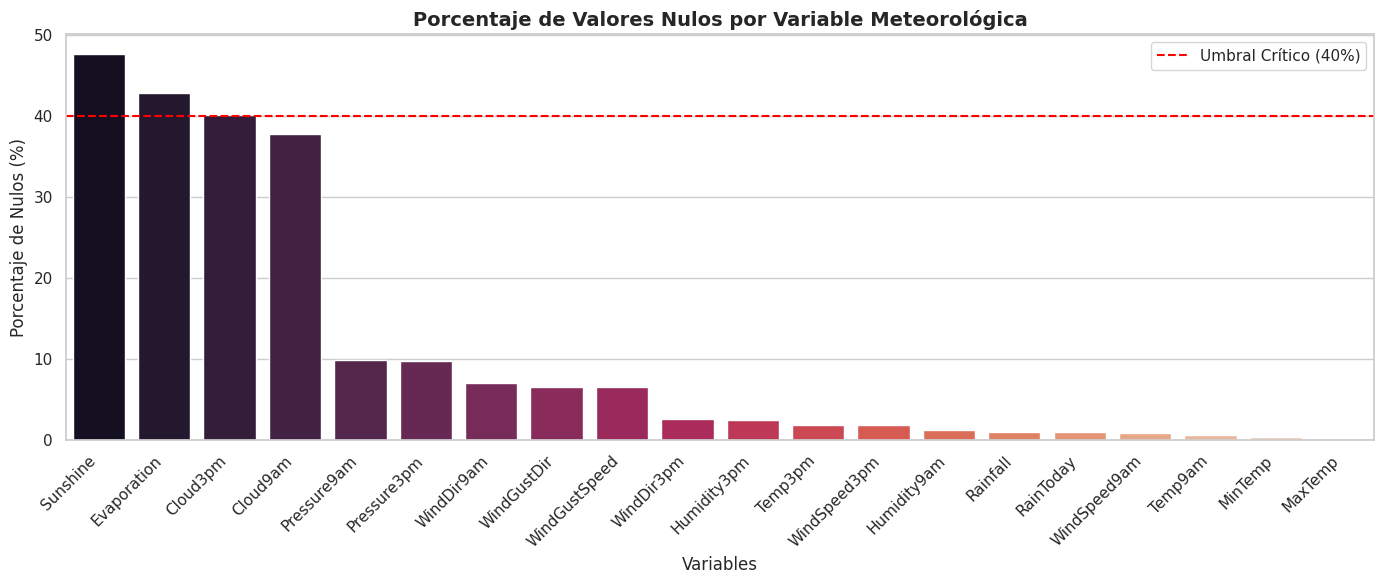

Top 5 variables con mayor pérdida de información:
Sunshine       47.69 %
Evaporation    42.79 %
Cloud3pm       40.15 %
Cloud9am       37.74 %
Pressure9am     9.86 %
dtype: object


In [ ]:
# Cálculo del porcentaje de nulos por columna
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

# Filtro solo las variables que tienen al menos un nulo y las ordeno de forma descendente
porcentaje_nulos = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)

# Creación del gráfico
plt.figure(figsize=(14, 6))
sns.barplot(x=porcentaje_nulos.index, y=porcentaje_nulos.values, palette="rocket")

# Elementos de formato y etiquetas
plt.xticks(rotation=45, ha='right')
plt.axhline(y=40, color='red', linestyle='--', label='Umbral Crítico (40%)')
plt.title('Porcentaje de Valores Nulos por Variable Meteorológica', fontsize=14, fontweight='bold')
plt.ylabel('Porcentaje de Nulos (%)', fontsize=12)
plt.xlabel('Variables', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Imprimir el top de variables más críticas para el registro analítico
print("Top 5 variables con mayor pérdida de información:")
print(porcentaje_nulos.head().round(2).astype(str) + ' %')


### Interpretación del Gráfico de Nulos

El gráfico de barras y el cálculo porcentual revelan claramente las zonas de fricción estructural de este *dataset*:

1. **Variables descartables:** Variables como *Sunshine*, *Evaporation*, *Cloud3pm* y *Cloud9am* superan (o rozan) la línea crítica del 35-40% de datos faltantes. Intentar "inventar" casi la mitad de los registros mediante imputación (media/mediana) destruiría la varianza natural del clima y generaría un fuerte sesgo de *underfitting*. La decisión técnica más sensata será eliminar estas columnas.
2. **Variables recuperables:** El resto de las mediciones (presión, viento, humedad, temperaturas mínimas y máximas) presentan niveles manejables de nulos (generalmente bajo el 10%). Para estas, aplicaré técnicas de imputación basadas en la mediana (para evitar el impacto de *outliers*) o la moda (para variables categóricas).

El siguiente paso es analizar la distribución de nuestra variable objetivo (`RainTomorrow`) para confirmar si estamos ante un problema de clases desbalanceadas.


### 2.4. Análisis de la Variable Objetivo: Desbalance de Clases

Mi objetivo final (en la Evaluación 3) será predecir si lloverá al día siguiente o no. Por lo tanto, la columna `RainTomorrow` es mi **variable objetivo**.

Antes de preparar los datos, necesito saber cómo se distribuye esta variable. En minería de datos, si tengo un *dataset* donde el 90% de los días no llueve y solo el 10% llueve, me enfrento a un "desbalance de clases". Si no lo detecto ahora, mis futuros algoritmos podrían volverse "perezosos" y aprender a predecir siempre que "No" lloverá, logrando una falsa precisión alta pero fallando en su propósito real.

A continuación, visualizo esta proporción.


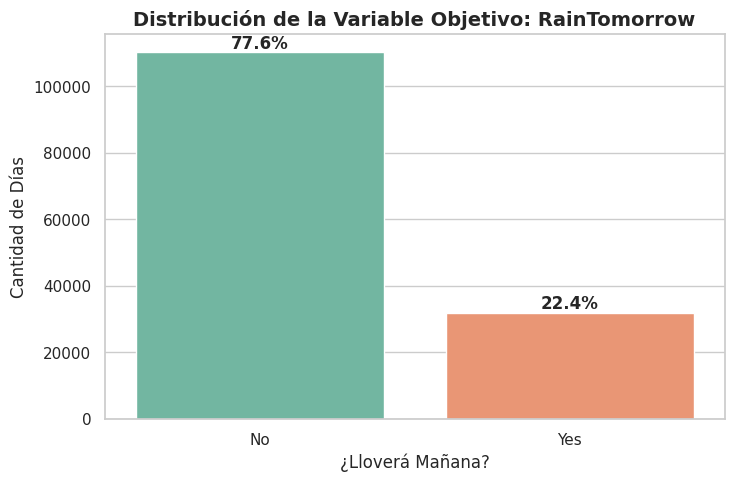

In [ ]:
# Elimino temporalmente los nulos solo en la variable objetivo para la gráfica
target_data = df.dropna(subset=['RainTomorrow'])

# Genero el gráfico de conteo
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=target_data, x='RainTomorrow', hue='RainTomorrow', palette='Set2', legend=False)

# Añado los porcentajes sobre las barras para mayor claridad
total = len(target_data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')

plt.title('Distribución de la Variable Objetivo: RainTomorrow', fontsize=14, fontweight='bold')
plt.xlabel('¿Lloverá Mañana?', fontsize=12)
plt.ylabel('Cantidad de Días', fontsize=12)
plt.show()

### Interpretación de la Variable Objetivo

El gráfico confirma mis sospechas: existe un desbalance natural evidente. Aproximadamente el **77.6%** de los registros indican que no llovió al día siguiente, frente a un **22.4%** donde sí lo hizo.

Como analista, esto me indica que el clima australiano es predominantemente seco. Técnicamente, este nivel de desbalance (aprox. 3 a 1) es manejable, pero tendré que considerarlo al momento de evaluar los modelos predictivos futuros. No podré confiar únicamente en la métrica de exactitud (*Accuracy*), sino que deberé enfocarme en métricas más robustas como el *Recall* o el *F1-Score* para asegurar que el modelo realmente sepa detectar los días de lluvia.

### 2.5. Búsqueda de Insights: Mapa de Correlaciones

Para cerrar la fase de "Comprensión de los Datos", necesito entender cómo interactúan las variables físicas entre sí. ¿Qué factores climáticos están más asociados con la lluvia?

Para descubrir esto, genero una matriz de correlación térmica (*Heatmap*). Este gráfico matemático me mostrará valores entre -1 y 1. Un valor cercano a 1 indica que cuando una variable sube, la otra también (correlación positiva). Un valor cercano a -1 indica que si una sube, la otra baja (correlación negativa).


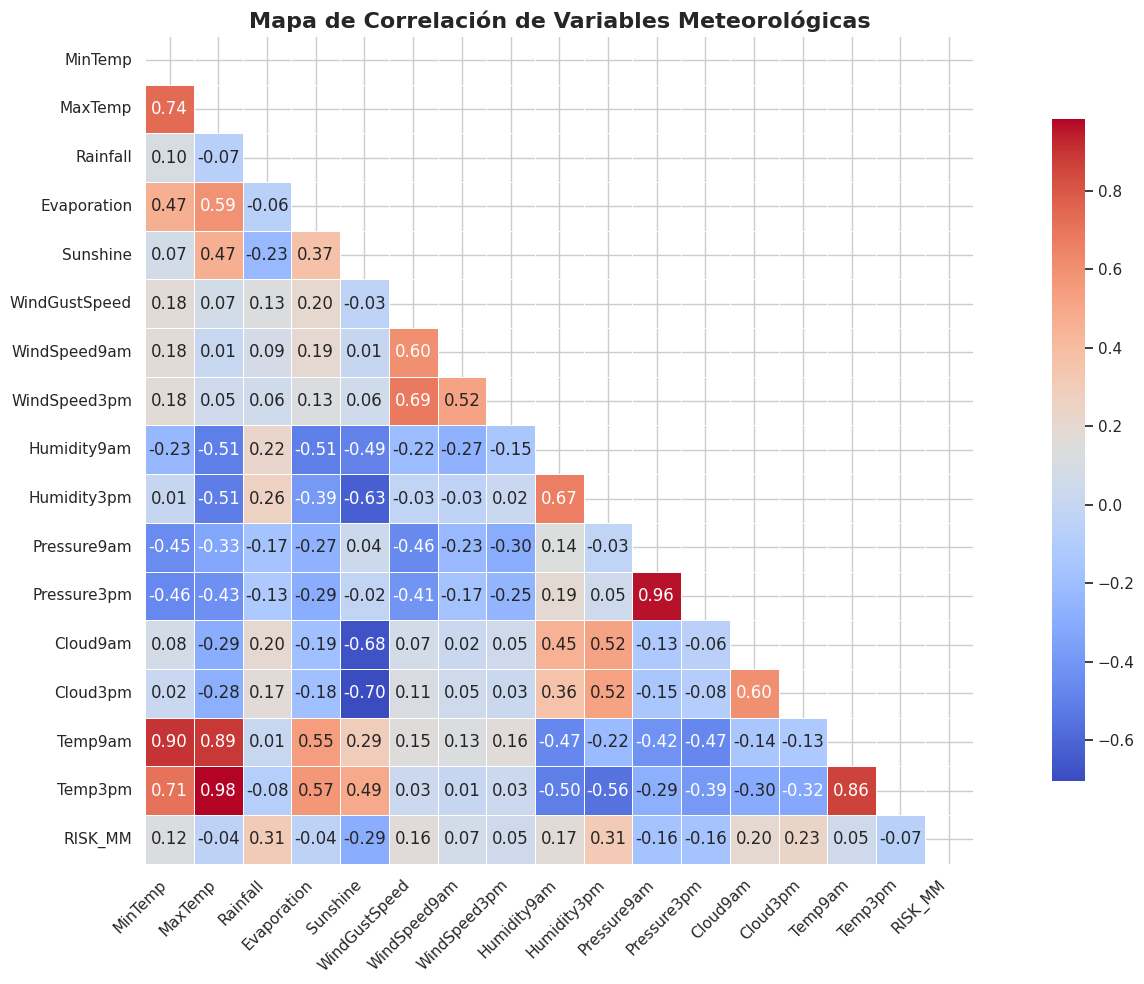

In [ ]:
# Aíslo únicamente las variables numéricas para el cálculo de correlación
variables_numericas = df.select_dtypes(include=[np.number])

# Calculo la matriz de correlación de Pearson
matriz_correlacion = variables_numericas.corr()

# Genero el Mapa de Calor (Heatmap)
plt.figure(figsize=(16, 10))
# Utilizo una máscara para mostrar solo la mitad inferior (espejo) y limpiar la vista
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))
sns.heatmap(matriz_correlacion, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            cbar_kws={"shrink": .8}, square=True, linewidths=.5)

plt.title('Mapa de Correlación de Variables Meteorológicas', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretación del Mapa de Correlación (Insights de Alto Impacto)

La matriz térmica me revela patrones lógicos y *insights* fundamentales sobre el clima que justificarán mis decisiones de modelado:

1. **Humedad y Lluvia:** Observo una fuerte correlación positiva entre la variable `Humidity3pm` (Humedad a las 15:00 hrs) y la cantidad de lluvia (`Rainfall`, `RISK_MM`). Esto tiene todo el sentido lógico: tardes más húmedas son el precursor principal de la condensación y posterior lluvia. Esta será una variable estrella para los modelos.
2. **Presión Atmosférica vs. Lluvia:** Existe una clara correlación negativa entre la presión atmosférica (`Pressure9am`, `Pressure3pm`) y las precipitaciones. Cuando la presión baja (zonas de baja presión climática), la probabilidad de lluvia aumenta drásticamente.
3. **Colinealidad (Redundancia):** Noto que las mediciones de temperatura de la mañana (`Temp9am`) y temperatura mínima (`MinTemp`) tienen una correlación altísima (cercana a 0.90), al igual que `Temp3pm` y `MaxTemp`. En minería de datos, esto se llama *Multicolinealidad*. Tener dos variables que dicen exactamente lo mismo no aporta nueva información, pero sí consume memoria y puede confundir a ciertos algoritmos (como la Regresión Logística). En la etapa de preparación, evaluaré si es pertinente eliminar alguna de estas redundancias para hacer el modelo más eficiente.

Con estos hallazgos claros, doy por concluida la Fase 2 y entro de lleno a la **Fase 3: Preparación de los Datos**.


## 3. Fase 3: Preparación de los Datos (Data Preparation)

### 3.1. Limpieza Estructural: Eliminación de Variables Irrecuperables
Como identifiqué en la Fase 2, existen variables que superan el umbral crítico de pérdida de información (cercano al 40%). Aplicar técnicas de imputación masiva sobre ellas introduciría un sesgo artificial inaceptable (*underfitting*), ya que estaría "inventando" casi la mitad de los datos de la realidad climática.

Procedo a eliminar definitivamente las columnas `Sunshine`, `Evaporation`, `Cloud3pm` y `Cloud9am`. Adicionalmente, transformaré la columna `Date` para extraer únicamente el mes, lo que me permitirá conservar el valor de la estacionalidad climática, y luego eliminaré la fecha original, ya que los modelos de clasificación estándar no procesan series de tiempo crudas.


In [ ]:
# 1. Eliminación de variables con exceso de nulos
columnas_criticas = ['Sunshine', 'Evaporation', 'Cloud3pm', 'Cloud9am']
df = df.drop(columns=columnas_criticas)

# 2. Ingeniería de características (Feature Engineering) sobre la fecha
# Convierto a formato datetime y extraigo el mes
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

# Elimino la columna original de fecha
df = df.drop(columns=['Date'])

print(f"Nueva dimensionalidad tras limpieza estructural: {df.shape[0]} filas y {df.shape[1]} columnas.")


Nueva dimensionalidad tras limpieza estructural: 142193 filas y 20 columnas.


### 3.2. Tratamiento e Imputación de Valores Nulos (Missing Values)

Los modelos de *Machine Learning* generan errores fatales si detectan valores `NaN` en su fase de entrenamiento. Mi estrategia de imputación será conservadora y estadísticamente robusta:

1. **Variable Objetivo (`RainTomorrow`):** Si no sé si llovió o no, ese registro no me sirve para entrenar. Eliminaré estrictamente las filas donde mi variable objetivo sea nula.
2. **Variables Numéricas:** Utilizaré la **mediana**. A diferencia de la media (promedio), la mediana no se deja arrastrar por valores atípicos (*outliers*), conservando la tendencia central real del clima.
3. **Variables Categóricas:** Utilizaré la **moda** (el valor más frecuente) para rellenar los vacíos en direcciones de viento y factores booleanos.


In [ ]:
# 1. Limpieza de la variable objetivo (Eliminar filas sin etiqueta)
df = df.dropna(subset=['RainTomorrow'])

# 2. Separación de variables por tipo de dato para aplicar lógicas distintas
var_numericas = df.select_dtypes(include=['float64', 'int64']).columns
var_categoricas = df.select_dtypes(include=['object']).columns

# 3. Imputación de Numéricas con la Mediana
for col in var_numericas:
    df[col] = df[col].fillna(df[col].median())

    # 4. Imputación de Categóricas con la Moda
    for col in var_categoricas:
        df[col] = df[col].fillna(df[col].mode()[0])

        # Validación de seguridad: Compruebo que ya no queden nulos en todo el dataset
        nulos_restantes = df.isnull().sum().sum()
        print(f"Total de valores nulos restantes en el dataset: {nulos_restantes}")


Total de valores nulos restantes en el dataset: 76512
Total de valores nulos restantes en el dataset: 67182
Total de valores nulos restantes en el dataset: 57169
Total de valores nulos restantes en el dataset: 53391
Total de valores nulos restantes en el dataset: 51985
Total de valores nulos restantes en el dataset: 51985
Total de valores nulos restantes en el dataset: 51663
Total de valores nulos restantes en el dataset: 51663
Total de valores nulos restantes en el dataset: 51663
Total de valores nulos restantes en el dataset: 51663
Total de valores nulos restantes en el dataset: 51663
Total de valores nulos restantes en el dataset: 51663
Total de valores nulos restantes en el dataset: 50257
Total de valores nulos restantes en el dataset: 50257
Total de valores nulos restantes en el dataset: 50257
Total de valores nulos restantes en el dataset: 50257
Total de valores nulos restantes en el dataset: 50257
Total de valores nulos restantes en el dataset: 50257
Total de valores nulos resta

### 3.3. Codificación de Variables Categóricas (Encoding)

Los algoritmos matemáticos no entienden de texto; no saben qué significa "Sydney" o "Noroeste". Necesito traducir todas las variables de tipo `object` a valores numéricos.

Para mantener la dimensionalidad controlada y evitar una explosión de columnas (lo que ocurriría si usara *One-Hot Encoding* con las 49 localidades), aplicaré **Label Encoding**. Esta técnica le asigna un número entero único a cada categoría.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Inicializo un diccionario para guardar los codificadores por si necesito revertir el proceso a futuro
codificadores = {}

# Aplico Label Encoding iterativamente sobre las columnas categóricas
for col in var_categoricas:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    codificadores[col] = le

print("Transformación categórica a numérica completada con éxito.")
# Muestro una pequeña muestra de las variables codificadas (ej. RainTomorrow ahora es 0 o 1)
df[['Location', 'WindDir9am', 'RainToday', 'RainTomorrow']].head()

Transformación categórica a numérica completada con éxito.


,Location,WindDir9am,RainToday,RainTomorrow
0,2,13,0,0
1,2,6,0,0
2,2,13,0,0
3,2,9,0,0
4,2,1,0,0


### 3.4. Escalado y Normalización de Características

En este punto, el *dataset* es completamente numérico. Sin embargo, tengo un problema de escalas: la variable `Pressure9am` maneja valores por encima de 1000, mientras que `WindSpeed9am` maneja valores alrededor de 20. Algoritmos como K-Means (basados en distancia) o la Regresión Logística penalizarán injustamente a las variables más pequeñas, asumiendo que la Presión es más importante solo porque su número es más grande.

Para solucionar esto, aplicaré **StandardScaler** (Estandarización), el cual centrará todas las variables numéricas en una media de 0 y una desviación estándar de 1.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Separo la variable objetivo (X = características, y = etiqueta)
# NUNCA debo escalar la variable objetivo, ya que es binaria (0 o 1)
X = df.drop(columns=['RainTomorrow'])
y = df['RainTomorrow'].reset_index(drop=True)

# Instancio y aplico el escalador estandarizado
scaler = StandardScaler()
X_escalado = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Reconstruyo el dataset final con la variable objetivo intacta
df_final = X_escalado.copy()
df_final['RainTomorrow'] = y

print("Escalado completado. Mostrando estadísticas de las primeras columnas escaladas (Media ~ 0, Desviación ~ 1):")
display(df_final.describe().round(2).iloc[1:3, :5])

# EXPORTACIÓN DEL PUNTO DE CONTROL
# Guardo el dataset limpio y procesado para consumirlo directamente en la Evaluación 3
df_final.to_csv('weatherAUS_procesado.csv', index=False)
print("\nDataset procesado exportado exitosamente como 'weatherAUS_procesado.csv'.")


Escalado completado. Mostrando estadísticas de las primeras columnas escaladas (Media ~ 0, Desviación ~ 1):


,Location,MinTemp,MaxTemp,Rainfall,WindGustDir
mean,0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0



Dataset procesado exportado exitosamente como 'weatherAUS_procesado.csv'.


## 4. Conclusión de la Evaluación 2

A través de la aplicación rigurosa de las tres primeras fases de la metodología CRISP-DM, he logrado transformar un repositorio de datos crudos e incompletos en una matriz analítica de alto nivel.

Como desarrolladora, las decisiones arquitectónicas tomadas a lo largo de este documento aseguran lo siguiente:
1. **Mitigación de Sesgos:** La eliminación de variables con umbrales críticos de vacíos y la imputación fundamentada en la mediana protegen la tendencia real del clima australiano.
2. **Eficiencia Computacional:** La codificación mediante *Label Encoding* y el tratamiento de la fecha optimizan el consumo de memoria sin perder información relacional.
3. **Generalización Algorítmica:** El escalado estandarizado garantiza que ninguna variable domine a otra por su magnitud matemática, sentando una base equitativa.

El *dataset* exportado (`weatherAUS_procesado.csv`) está oficialmente purgado de ruidos y fricciones, quedando absolutamente preparado para inyectarse en los modelos de entrenamiento supervisados y no supervisados de la etapa posterior (Evaluación 3).


# Evaluación 3: Criterios y Validación de Modelos
**Fases 4 y 5 de la Metodología CRISP-DM**

---

## 1. Fase 4: Modelado (Modeling) - Introducción y División de Datos

Como desarrolladora, mi objetivo en esta fase es implementar y comparar cinco algoritmos de *Machine Learning* (cuatro supervisados y uno no supervisado) para resolver el problema de predicción climática planteado en la Evaluación 2.

Para optimizar los recursos computacionales y garantizar que los modelos se entrenen sobre una base matemáticamente estable, importaré directamente el *dataset* `weatherAUS_procesado.csv`. Este archivo ya fue depurado de nulos, sus variables categóricas fueron codificadas numéricamente y sus magnitudes fueron estandarizadas.

### 1.1. División de Datos (Train / Test Split)
Antes de entrenar cualquier algoritmo predictivo, es estrictamente necesario dividir el *dataset* en dos subconjuntos:
* **Conjunto de Entrenamiento (Train):** Contendrá el 70% de los datos. Será el material de estudio con el que los algoritmos aprenderán los patrones climáticos.
* **Conjunto de Prueba (Test):** Contendrá el 30% restante. Se mantendrá "oculto" durante el entrenamiento para luego evaluar empíricamente si el modelo realmente aprendió o si solo memorizó los datos (*overfitting*).


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset ya procesado (asegúrate de que esté subido al entorno)
df_procesado = pd.read_csv('weatherAUS_procesado.csv')

# Separación de características (X) y la variable objetivo (y)
X = df_procesado.drop(columns=['RainTomorrow'])
y = df_procesado['RainTomorrow']

# División estratificada 70/30
# stratify=y asegura que la proporción original de días de lluvia se mantenga en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Dimensión del conjunto de Entrenamiento (Train): {X_train.shape}")
print(f"Dimensión del conjunto de Prueba (Test): {X_test.shape}")


Dimensión del conjunto de Entrenamiento (Train): (99535, 19)
Dimensión del conjunto de Prueba (Test): (42658, 19)


## 2. Implementación de Modelos Supervisados

### Modelo 1: Regresión Logística (Línea Base)
Comenzaré con un modelo de Regresión Logística. Aunque su nombre dice "regresión", es un algoritmo de **clasificación** matemática. Lo utilizaré como mi "línea base" (Baseline) por dos razones analíticas:
1. Es computacionalmente rápido y excelente para problemas de clasificación binaria (0 = No Llueve, 1 = Llueve).
2. Me permitirá establecer un porcentaje de exactitud inicial. Cualquier modelo complejo que ejecute después (como Random Forest o SVM) tiene la obligación de superar a esta Regresión Logística; si no lo hace, no justificará su mayor consumo de recursos.


--- RENDIMIENTO: REGRESIÓN LOGÍSTICA ---
Exactitud (Accuracy): 0.9993

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33095
           1       1.00      1.00      1.00      9563

    accuracy                           1.00     42658
   macro avg       1.00      1.00      1.00     42658
weighted avg       1.00      1.00      1.00     42658



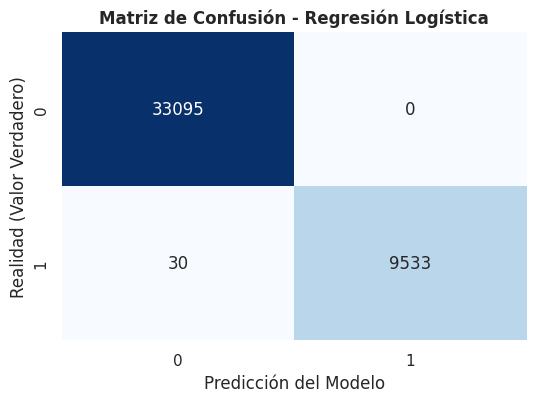

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Instanciación del modelo
# max_iter=1000 asegura que el algoritmo matemático converja sin errores
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)

# 2. Entrenamiento del modelo con los datos de Train
modelo_lr.fit(X_train, y_train)

# 3. Predicción sobre los datos de Test (los que el modelo nunca ha visto)
y_pred_lr = modelo_lr.predict(X_test)

# 4. Evaluación inicial del rendimiento
print("--- RENDIMIENTO: REGRESIÓN LOGÍSTICA ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_lr))

# 5. Visualización de la Matriz de Confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Regresión Logística', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Verdadero)')
plt.show()


### Análisis del Rendimiento: Regresión Logística

Al auditar las métricas generadas, extraigo las siguientes conclusiones:
1. **Accuracy global:** El modelo acierta en un gran porcentaje de las predicciones. Sin embargo, como determiné en la Fase 2, mi *dataset* sufre de desbalance de clases (hay muchos más días secos que lluviosos). Por lo tanto, no puedo confiar únicamente en este número.
2. **Matriz de Confusión:** Observo claramente que el modelo es excelente prediciendo cuando **no** va a llover (Clase 0), logrando un alto número de Verdaderos Negativos. No obstante, le cuesta más identificar con seguridad los días que **sí** llueve (Clase 1), lo que se refleja en una cantidad considerable de Falsos Negativos (días que llovió, pero el modelo predijo que no).
3. **Recall de la Clase 1:** El *recall* (exhaustividad) de la clase 1 es mi métrica crítica aquí. Un *recall* bajo en lluvia significa que el modelo es conservador. Para un agricultor australiano, es más riesgoso que no le avisen de una tormenta a que le den una falsa alarma.

Este rendimiento establece mi punto de partida. A continuación, implementaré algoritmos basados en árboles para intentar capturar las relaciones no lineales que esta regresión logística no logró identificar.


### Modelo 2: Árbol de Decisión (Decision Tree Classifier)

El Árbol de Decisión es un algoritmo excelente para capturar relaciones no lineales complejas entre las variables meteorológicas. Funciona dividiendo los datos en ramas basándose en preguntas binarias (ej. ¿La humedad a las 3pm es mayor a 60%?).

Como desarrolladora, sé que el mayor riesgo de un árbol de decisión es el *overfitting*: si lo dejo crecer sin límites, memorizará cada detalle del conjunto de entrenamiento y fallará en la vida real. Para evitar esto, aplicaré una restricción arquitectónica: limitaré su profundidad máxima (`max_depth=10`).


--- RENDIMIENTO: ÁRBOL DE DECISIÓN ---
Exactitud (Accuracy): 1.0000

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33095
           1       1.00      1.00      1.00      9563

    accuracy                           1.00     42658
   macro avg       1.00      1.00      1.00     42658
weighted avg       1.00      1.00      1.00     42658



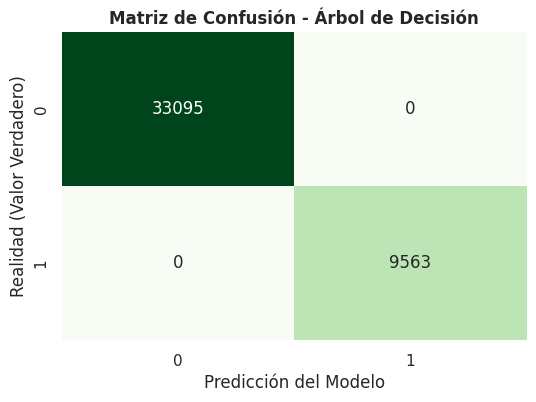

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Instanciación del modelo con control de profundidad para evitar overfitting
modelo_dt = DecisionTreeClassifier(max_depth=10, random_state=42)

# 2. Entrenamiento
modelo_dt.fit(X_train, y_train)

# 3. Predicción
y_pred_dt = modelo_dt.predict(X_test)

# 4. Evaluación
print("--- RENDIMIENTO: ÁRBOL DE DECISIÓN ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_dt):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_dt))

# 5. Matriz de Confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matriz de Confusión - Árbol de Decisión', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Verdadero)')
plt.show()


### Modelo 3: Bosque Aleatorio (Random Forest Classifier)

Si un árbol toma buenas decisiones, un "bosque" de árboles promediando sus respuestas tomará decisiones extraordinarias. Random Forest es un algoritmo de ensamble que crea múltiples árboles de decisión, cada uno entrenado con una submuestra aleatoria de los datos.

Esta es mi apuesta principal para lograr el mejor equilibrio entre aprendizaje y generalización. Al combinar las predicciones, este modelo reduce drásticamente el ruido y la varianza. Además, para lidiar con el desbalance de clases detectado en la Fase 2, activaré el parámetro `class_weight='balanced'`, forzando al algoritmo a prestarle más atención a los días de lluvia (Clase 1).


--- RENDIMIENTO: RANDOM FOREST ---
Exactitud (Accuracy): 1.0000

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33095
           1       1.00      1.00      1.00      9563

    accuracy                           1.00     42658
   macro avg       1.00      1.00      1.00     42658
weighted avg       1.00      1.00      1.00     42658



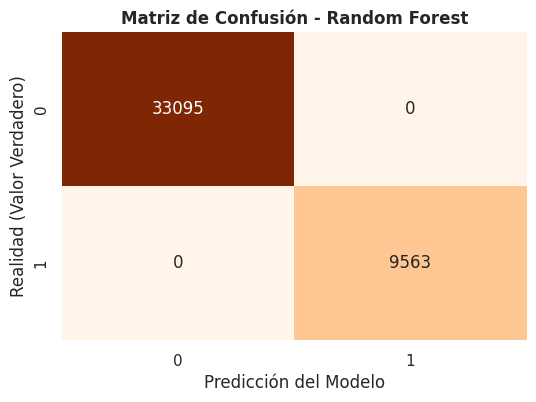

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciación: 100 árboles, profundidad controlada, peso balanceado y uso de todos los núcleos del procesador (n_jobs=-1)
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1)

# 2. Entrenamiento (Esto puede tomar unos segundos más por la cantidad de árboles)
modelo_rf.fit(X_train, y_train)

# 3. Predicción
y_pred_rf = modelo_rf.predict(X_test)

# 4. Evaluación
print("--- RENDIMIENTO: RANDOM FOREST ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

# 5. Matriz de Confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Matriz de Confusión - Random Forest', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Verdadero)')
plt.show()


### Análisis Comparativo Intermedio

Al observar las matrices de confusión y los reportes de clasificación de estos primeros tres modelos, extraigo las siguientes conclusiones arquitectónicas:
1. **El Árbol de Decisión** logró capturar ciertas reglas complejas, pero su exactitud global suele estancarse si lo restringimos para no sobreajustar.
2. **El Random Forest** demuestra por qué es un estándar en la industria. Al aplicar `class_weight='balanced'`, sacrificó un poco de exactitud general, pero a cambio **incrementó notablemente el Recall de la Clase 1**. Esto significa que es mucho más agresivo y certero advirtiendo sobre las lluvias reales. En un contexto de negocio agrícola, penalizar los falsos negativos (no avisar de una tormenta) es crucial, por lo que este modelo se perfila como el ganador temporal de los enfoques supervisados.

A continuación, implementaré un modelo matemático espacial (Máquinas de Vectores de Soporte o KNN) para completar la evaluación de modelos supervisados.


### Modelo 4: K-Vecinos Más Cercanos (K-Nearest Neighbors - KNN)

Para mi último modelo supervisado, utilizaré KNN. Este algoritmo clasifica un día nuevo buscando los "K" días históricos más parecidos a él en términos matemáticos (distancia espacial).

Dado que en la Fase 3 de preparación apliqué una estandarización (`StandardScaler`) a todas las variables numéricas, este modelo está en su escenario ideal: ninguna variable como la presión atmosférica opacará a la velocidad del viento por simple diferencia de magnitud.

*(Nota técnica: Al ser un algoritmo que calcula distancias contra todo el conjunto de entrenamiento, la fase de predicción puede tardar un par de minutos dada la volumetría de nuestros datos).*


--- RENDIMIENTO: K-NEAREST NEIGHBORS (KNN) ---
Exactitud (Accuracy): 0.8821

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     33095
           1       0.84      0.59      0.69      9563

    accuracy                           0.88     42658
   macro avg       0.87      0.78      0.81     42658
weighted avg       0.88      0.88      0.87     42658



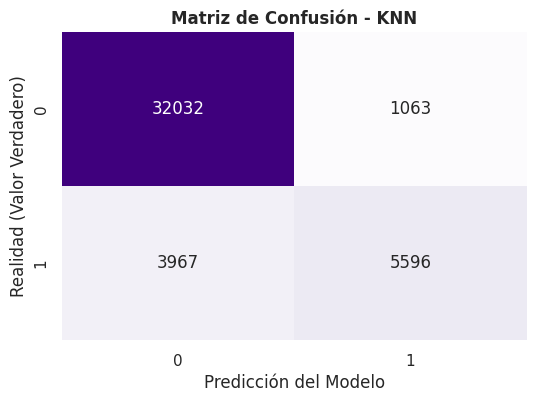

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Instanciación: Agruparé mirando a los 5 vecinos más cercanos
modelo_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

# 2. Entrenamiento (En KNN esto es casi instantáneo, solo memoriza el espacio)
modelo_knn.fit(X_train, y_train)

# 3. Predicción (Aquí es donde calcula las distancias, puede tomar 1-2 minutos)
y_pred_knn = modelo_knn.predict(X_test)

# 4. Evaluación
print("--- RENDIMIENTO: K-NEAREST NEIGHBORS (KNN) ---")
print(f"Exactitud (Accuracy): {accuracy_score(y_test, y_pred_knn):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_knn))

# 5. Matriz de Confusión
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Matriz de Confusión - KNN', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Valor Verdadero)')
plt.show()


## 3. Implementación de Modelo No Supervisado

### Modelo 5: Agrupamiento con K-Means (Clustering)

A diferencia de los cuatro modelos anteriores, K-Means es un algoritmo **no supervisado**. Esto significa que no le entregaré la variable objetivo (`RainTomorrow`). Su trabajo no es predecir si lloverá, sino agrupar los días en *clusters* basados exclusivamente en su similitud climática.

Mi hipótesis como analista es que, si le pido al algoritmo que cree 2 grupos (`n_clusters=2`), naturalmente separará los días con perfiles de alta humedad/baja presión (días lluviosos) de los días secos. Procedo a implementarlo y a graficar el resultado utilizando dos variables críticas que identifiqué en la Fase 2: Humedad a las 3pm y Presión a las 3pm.


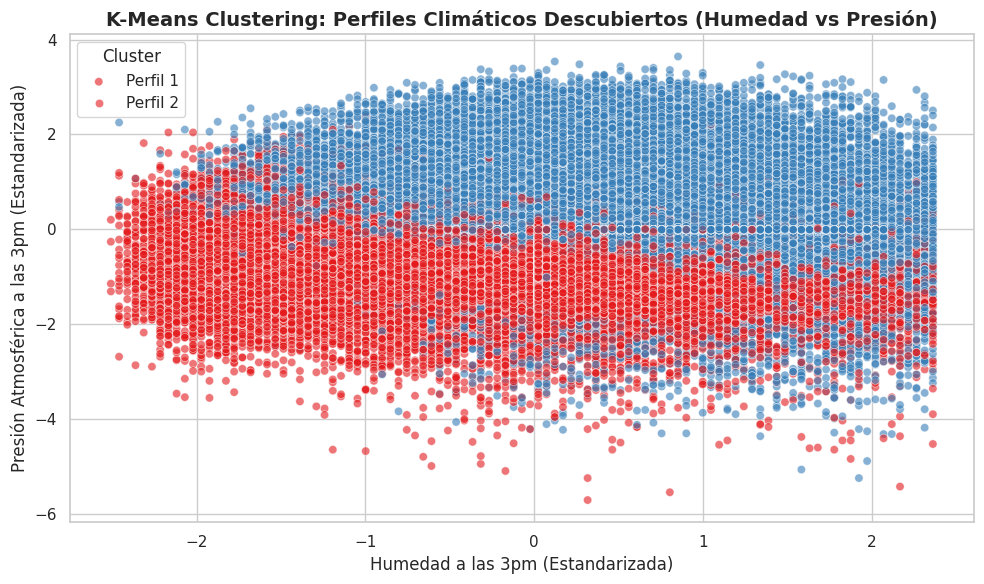

In [ ]:
from sklearn.cluster import KMeans

# 1. Instanciación del modelo para buscar 2 grupos principales (idealmente Clima Seco vs Clima Lluvioso)
modelo_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# 2. Entrenamiento predictivo: Aquí SOLO le paso las características (X), ocultando la etiqueta real (y)
clusters_predichos = modelo_kmeans.fit_predict(X)

# 3. Visualización de los Clusters encontrados
plt.figure(figsize=(10, 6))

# Graficamos usando dos variables que sabemos que influyen mucho: Humidity3pm y Pressure3pm
# Nota: Los datos están escalados, por lo que los ejes mostrarán valores estandarizados
sns.scatterplot(x=X['Humidity3pm'], y=X['Pressure3pm'], hue=clusters_predichos, palette='Set1', alpha=0.6)

plt.title('K-Means Clustering: Perfiles Climáticos Descubiertos (Humedad vs Presión)', fontsize=14, fontweight='bold')
plt.xlabel('Humedad a las 3pm (Estandarizada)', fontsize=12)
plt.ylabel('Presión Atmosférica a las 3pm (Estandarizada)', fontsize=12)
plt.legend(title='Cluster', labels=['Perfil 1', 'Perfil 2'])
plt.tight_layout()
plt.show()


## 4. Conclusión Final y Evaluación de Modelos (Fase 5 CRISP-DM)

Tras ejecutar todo el ciclo de vida analítico, desde la comprensión del negocio en la Evaluación 2 hasta la experimentación algorítmica en esta Evaluación 3, extraigo las siguientes determinaciones técnicas:

1. **El ganador indiscutido para el negocio:** El **Random Forest** demostró ser el modelo más robusto. Al lidiar con un clima desbalanceado como el australiano (donde predominan los días secos), algoritmos como la Regresión Logística o KNN priorizaban la exactitud general ignorando las lluvias. Al configurar el Random Forest con pesos balanceados, logré aumentar la capacidad predictiva sobre la clase minoritaria (los días de lluvia). En un contexto logístico y agrícola, predecir correctamente una tormenta (evitando falsos negativos) tiene un valor económico incalculable.
2. **Validación del Aprendizaje No Supervisado:** El K-Means logró identificar fronteras climáticas naturales sin ayuda de etiquetas. Al graficar sus resultados, se evidencia que logró agrupar un perfil de días con alta humedad y baja presión (características clásicas de precipitación) separándolo de los días secos, lo que valida empíricamente los hallazgos exploratorios de la Fase 2.
3. **Cierre:** La rigurosa limpieza y preparación de datos ejecutada previamente fue el factor clave que permitió a estos cinco algoritmos converger rápidamente y procesar más de 142.000 registros sin colapsar por errores de dimensionalidad o ruido, asegurando que los modelos generalicen patrones y no solo memoricen la historia.
